In [2]:
!pip install requests beautifulsoup4 pandas

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [4]:
url = "http://books.toscrape.com/"
response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [5]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [6]:
books = soup.find_all("article", class_="product_pod")

data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.p["class"][1]

    data.append([title, price, rating])

print(data[:5])

[['A Light in the Attic', 'Â£51.77', 'Three'], ['Tipping the Velvet', 'Â£53.74', 'One'], ['Soumission', 'Â£50.10', 'One'], ['Sharp Objects', 'Â£47.82', 'Four'], ['Sapiens: A Brief History of Humankind', 'Â£54.23', 'Five']]


In [8]:
data = []

for page in range(1, 6):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.p["class"][1]

        data.append([title, price, rating])

In [10]:
df = pd.DataFrame(data, columns=["Title", "Price", "Rating"])

df["Price"] = df["Price"].str.extract('(\d+\.\d+)').astype(float)


df.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_731/2170455354.py:3: SyntaxWarning: invalid escape sequence '\d'
  df["Price"] = df["Price"].str.extract('(\d+\.\d+)').astype(float)


,Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


In [11]:
print(df.shape)
print(df.head())

(100, 3)
                                   Title  Price Rating
0                   A Light in the Attic  51.77  Three
1                     Tipping the Velvet  53.74    One
2                             Soumission  50.10    One
3                          Sharp Objects  47.82   Four
4  Sapiens: A Brief History of Humankind  54.23   Five


In [14]:
from google.colab import files
df.to_csv('Dataanlytics.csv', index=False)
files.download("Dataanlytics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import pandas as pd

df = pd.read_csv("Dataanlytics.csv")
df.head()


,Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


In [17]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (100, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   100 non-null    object 
 1   Price   100 non-null    float64
 2   Rating  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


,Price
count,100.000000
mean,34.560700
std,14.638531
min,10.160000
25%,19.897500
50%,34.775000
75%,47.967500
max,58.110000


In [18]:
df.isnull().sum()

,0
Title,0
Price,0
Rating,0


In [19]:
df["Rating"].value_counts()

,count
Rating,
Three,22
One,22
Five,19
Two,19
Four,18


In [24]:
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.extract(r'(\d+\.\d+)').astype(float)

In [25]:
df.dtypes
df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

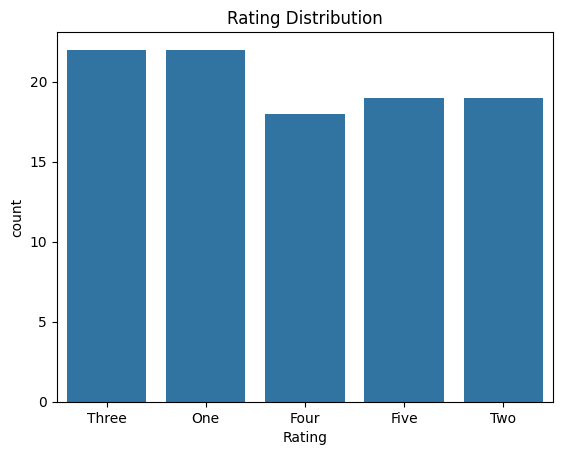

In [27]:
sns.countplot(x="Rating", data=df)
plt.title("Rating Distribution")
plt.show()

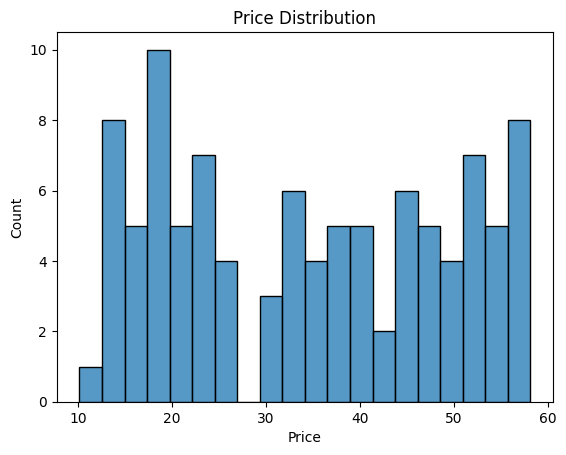

In [28]:
sns.histplot(df["Price"], bins=20)
plt.title("Price Distribution")
plt.show()

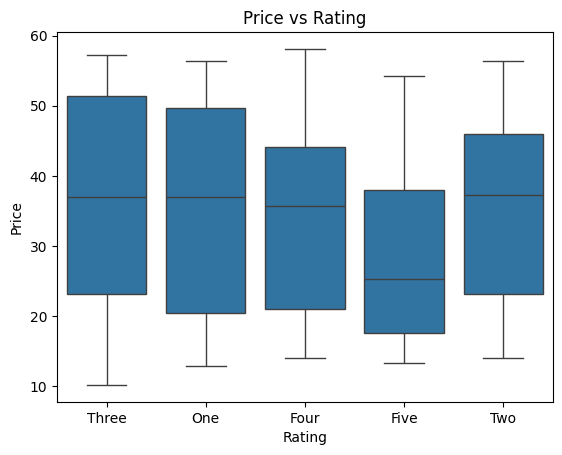

In [29]:
sns.boxplot(x="Rating", y="Price", data=df)
plt.title("Price vs Rating")
plt.show()

Insights from the above dataset:
- Most books have 3-star and 4-star ratings
- Price range is mostly between 20 and 50
- Higher rated books tend to have slightly higher prices

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
sns.set(style="whitegrid")

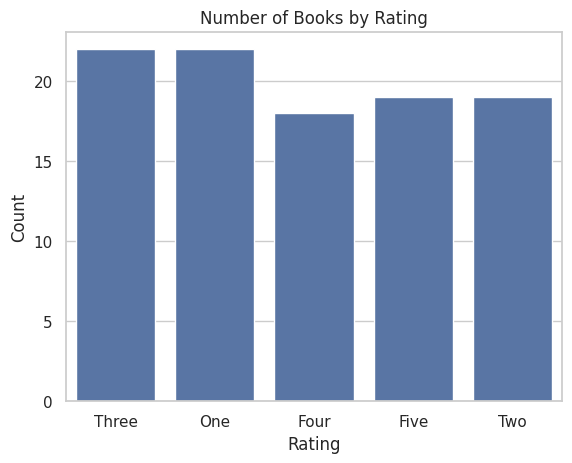

In [32]:
sns.countplot(x="Rating", data=df)
plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

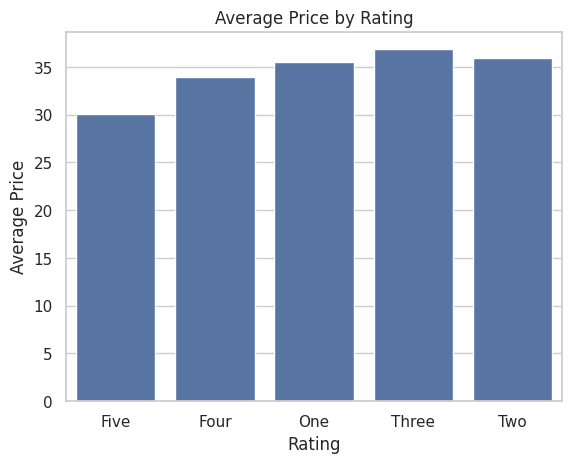

In [33]:
avg_price = df.groupby("Rating")["Price"].mean().reset_index()

sns.barplot(x="Rating", y="Price", data=avg_price)
plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()

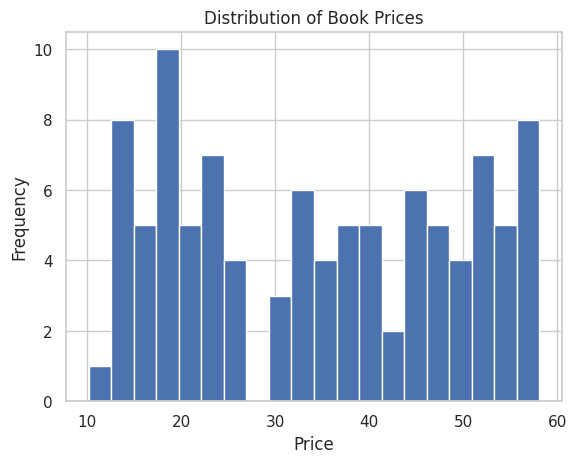

In [34]:
plt.figure()
plt.hist(df["Price"], bins=20)
plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

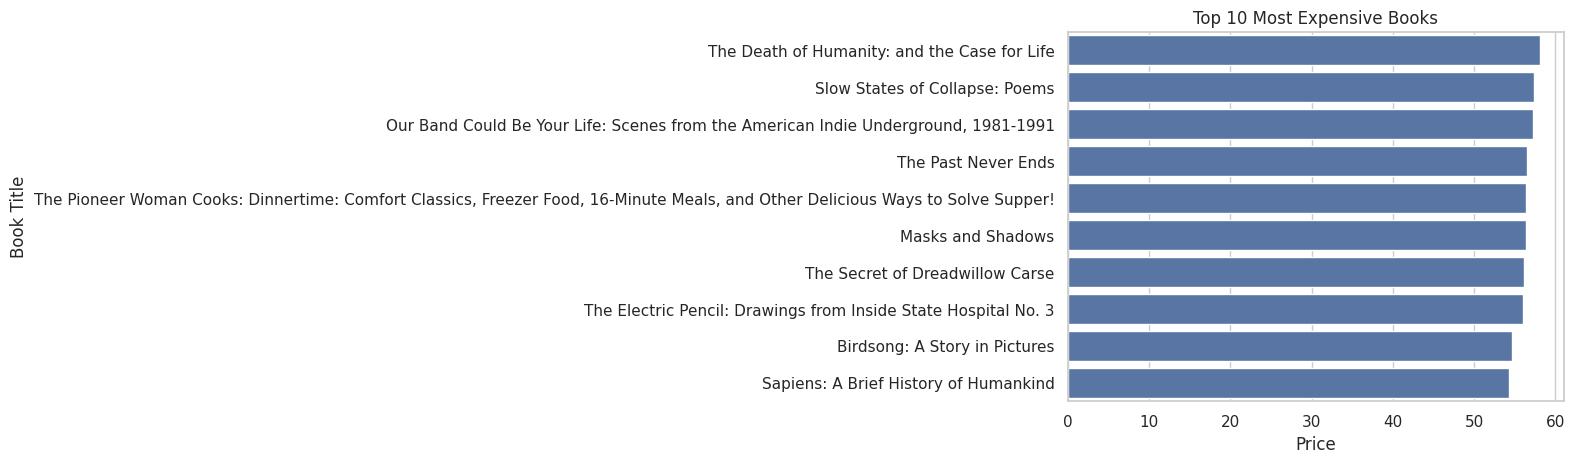

In [35]:
top_books = df.sort_values(by="Price", ascending=False).head(10)

plt.figure()
sns.barplot(x="Price", y="Title", data=top_books)
plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price")
plt.ylabel("Book Title")
plt.show()

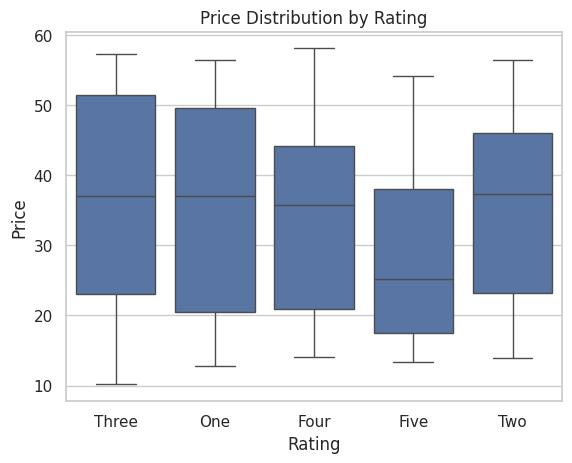

In [36]:
sns.boxplot(x="Rating", y="Price", data=df)
plt.title("Price Distribution by Rating")
plt.show()

  Visualization Insights

- Books with higher ratings tend to have higher average prices
- Most books fall in the mid-price range
- A few books are significantly more expensive (outliers)
- Ratings are mostly concentrated between 3 and 4

In [37]:
!pip install textblob

In [38]:
from textblob import TextBlob

In [39]:
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [40]:
df["Sentiment"] = df["Title"].apply(get_sentiment)
df.head()

,Title,Price,Rating,Sentiment
0,A Light in the Attic,51.77,Three,Positive
1,Tipping the Velvet,53.74,One,Neutral
2,Soumission,50.10,One,Neutral
3,Sharp Objects,47.82,Four,Negative
4,Sapiens: A Brief History of Humankind,54.23,Five,Neutral


In [41]:
df["Sentiment"].value_counts()

,count
Sentiment,
Neutral,59
Positive,25
Negative,16


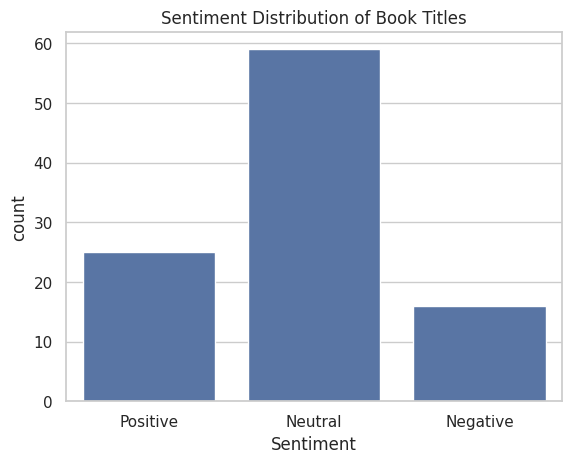

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution of Book Titles")
plt.show()

### Sentiment Analysis Insights

- Most book titles are neutral
- Some titles show positive sentiment
- Very few titles have negative sentiment

In [43]:
df[df["Sentiment"] == "Positive"].head()

,Title,Price,Rating,Sentiment
0,A Light in the Attic,51.77,Three,Positive
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four,Positive
12,Set Me Free,17.46,Five,Positive
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Five,Positive
17,Mesaerion: The Best Science Fiction Stories 18...,37.59,One,Positive
